In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [7]:
df = pd.read_csv("telco-customer-churn.csv")

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
df.shape

(7043, 21)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [17]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [19]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Customer Churn Distribution

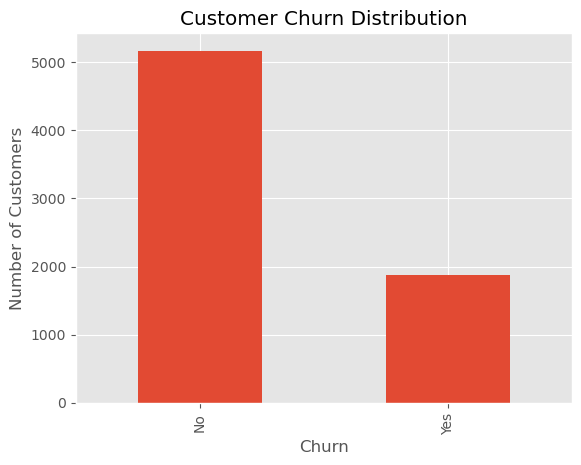

In [23]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Interpretation
Most customers did not churn, but a significant proportion left the company. This indicates that customer retention remains an important business challenge.

----

# Churn by Contract Type

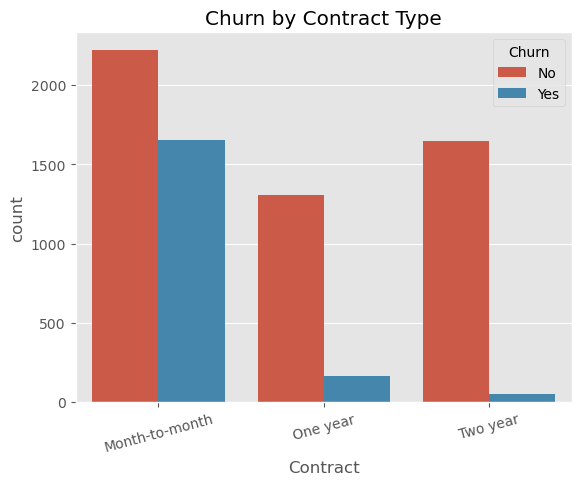

In [24]:
sns.countplot(data=df, x="Contract", hue="Churn")

plt.xticks(rotation=15)
plt.title("Churn by Contract Type")

plt.show()

In [45]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index").mul(100).round(1)

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


## Interpretation
Customers on month-to-month contracts have the highest churn rate, with 42.7% of customers in this contract type leaving the company. In comparison, only 11.3% of customers on one-year contracts and 2.8% of customers on two-year contracts churned. This indicates a strong association between longer-term contracts and higher customer retention, suggesting that contract duration plays an important role in customer loyalty.

---

# Churn by Payment Method

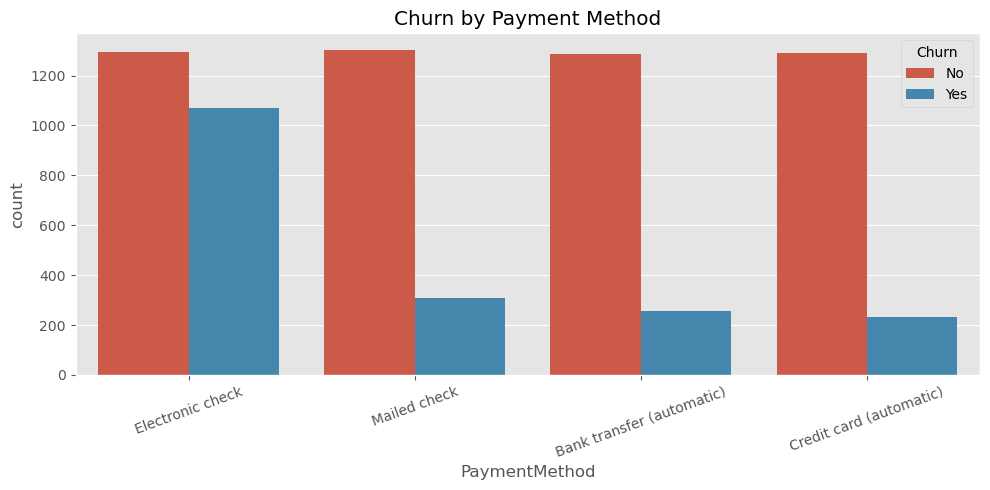

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=20)
plt.title("Churn by Payment Method")
plt.tight_layout()
plt.show()

In [49]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").mul(100).round(1)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


## Interpretation

Payment method is associated with customer churn. Customers who use Electronic Check have the highest churn rate at 45.3%, substantially higher than customers using Mailed Check (19.1%), Bank Transfer (Automatic) (16.7%), or Credit Card (Automatic) (15.2%). This suggests that customers paying by Electronic Check are considerably more likely to churn than customers using other payment methods.

---

# Overall Customer Churn

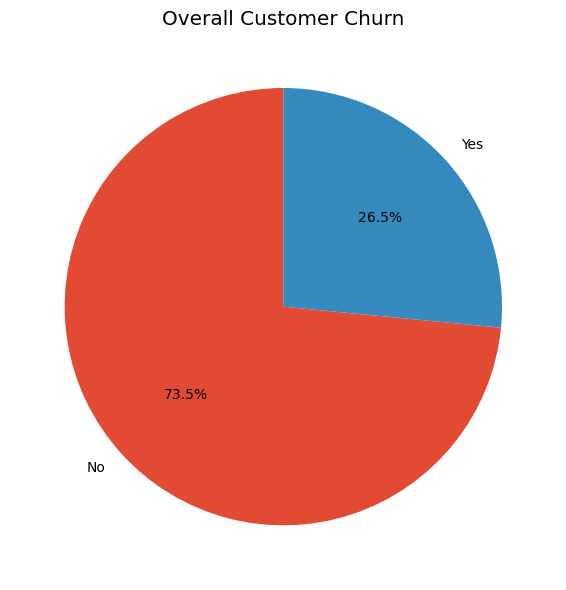

In [26]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Customer Churn")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Interpretation

Approximately three-quarters of customers remained with the company, while about one-quarter churned. Although most customers stayed, the churn rate is still substantial enough to affect business performance.

---

# Contract Type Distribution

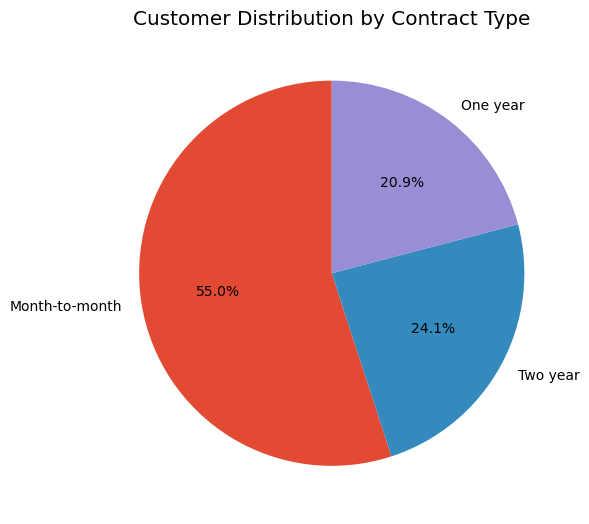

In [27]:
plt.figure(figsize=(6,6))

df["Contract"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Contract Type")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Interpretation

Most customers are on month-to-month contracts, while fewer customers have one-year or two-year contracts. This may help explain why churn is higher among month-to-month customers.

---

# Customer Tenure Distribution

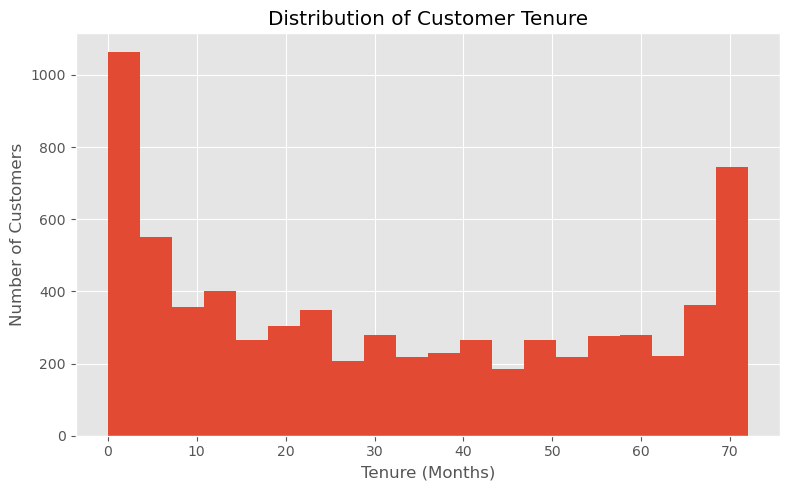

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=20)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [29]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [30]:
pd.cut(df["tenure"], bins=[0,12,24,48,72]).value_counts().sort_index()

tenure
(0, 12]     2175
(12, 24]    1024
(24, 48]    1594
(48, 72]    2239
Name: count, dtype: int64

## Interpretation
The tenure distribution shows that 31.8% (2,239) of customers fall within the 48–72 month tenure range, while 30.9% (2,175) have a tenure of 0–12 months. This indicates that the dataset contains both a substantial group of long-tenured customers and a similarly large group of newer customers

---

# Monthly Charges Distribution

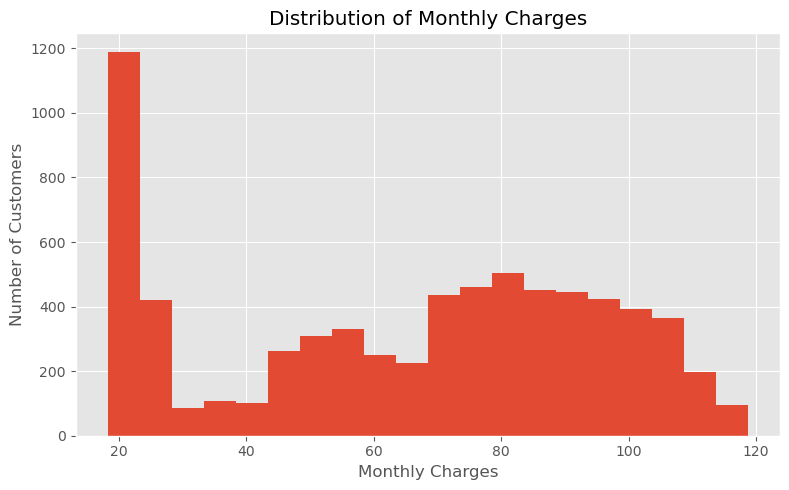

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [32]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [33]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

## Interpretation
The monthly charges distribution shows that 38.1% (2,681) of customers pay between $70 and $100 per month, making it the most common pricing range. In comparison, 12.8% (902) of customers pay more than $100 per month.

---

# Monthly Charges by Churn

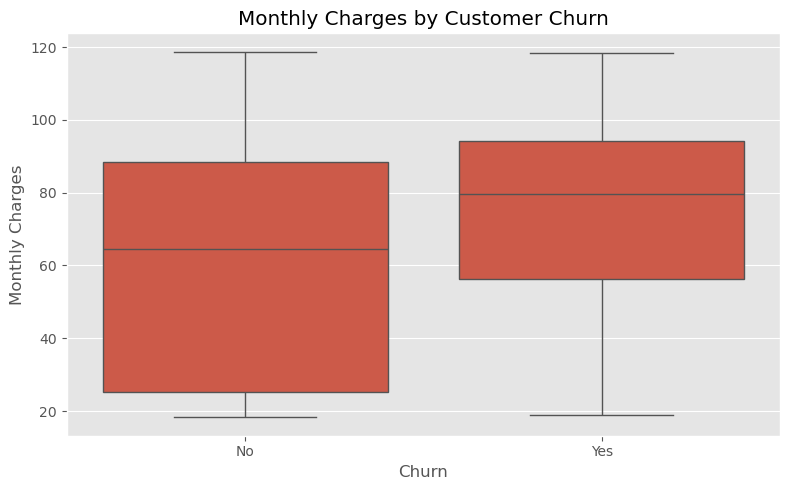

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

## Interpretation

Customers who churned tended to have higher monthly charges than customers who remained. The median monthly charge for churned customers is noticeably higher, indicating an association between higher monthly charges and customer churn. While this pattern does not prove that higher prices cause customers to leave, it highlights an area for further investigation.

---

# Correlation Heatmap

In [35]:
numeric_df = df.select_dtypes(include=["number"])

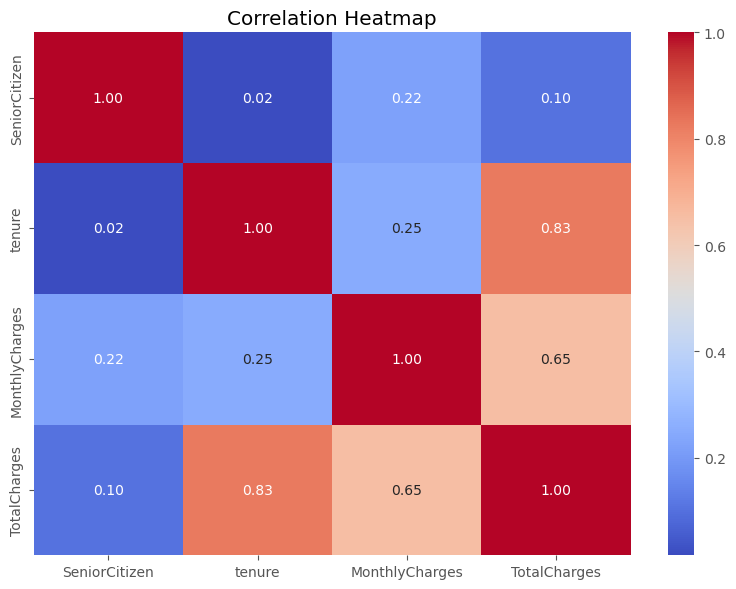

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Interpretation

The correlation heatmap shows a strong positive correlation between Tenure and Total Charges (0.83), indicating that customers with longer tenures generally accumulate higher total charges. Monthly Charges also show a moderate positive correlation with Total Charges (0.65). In contrast, Tenure has only a weak positive correlation with Monthly Charges (0.25), suggesting that customers who stay longer do not necessarily pay higher monthly fees. Senior Citizen status exhibits very weak correlations with the other numeric variables, indicating little or no linear relationship with tenure or charges.

---

# Internet Service

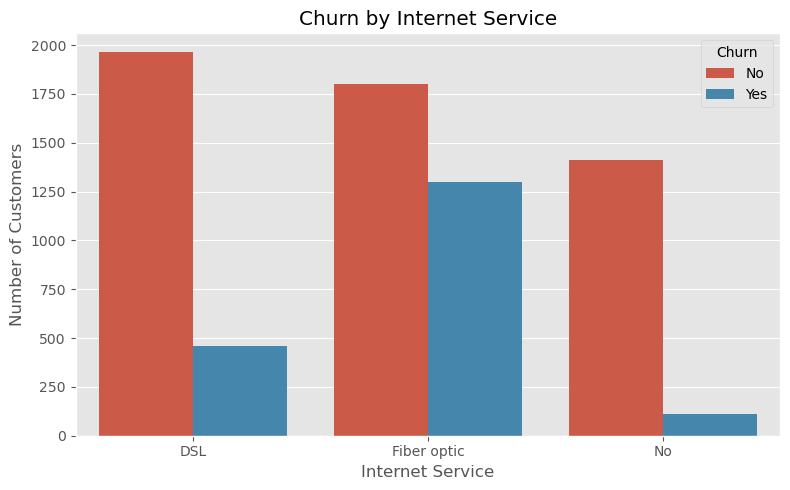

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [50]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index").mul(100).round(1)

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


## Interpretation

Internet service type is strongly associated with customer churn. Customers using Fiber Optic internet have the highest churn rate at 41.9%, compared with 19.0% for DSL customers and 7.4% for customers without internet service. These findings suggest that Fiber Optic customers are considerably more likely to churn than customers in the other internet service categories.

---

# Online Security

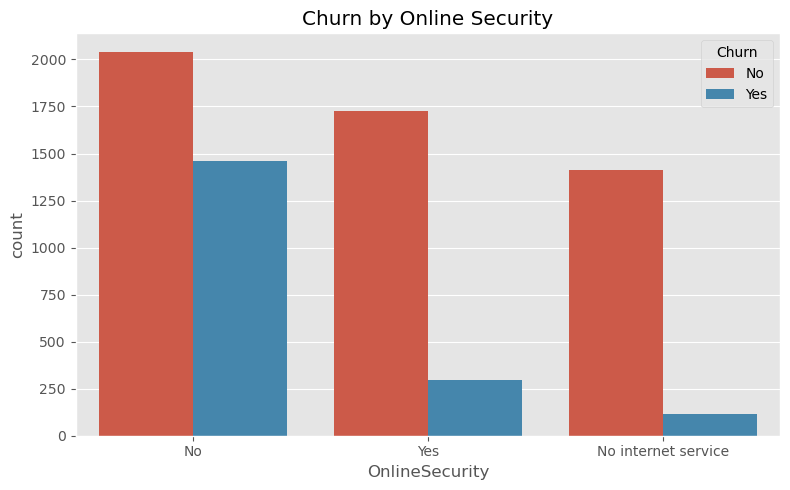

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="OnlineSecurity", hue="Churn")

plt.title("Churn by Online Security")

plt.tight_layout()
plt.show()

In [51]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index").mul(100).round(1)

Churn,No,Yes
OnlineSecurity,,
No,58.2,41.8
No internet service,92.6,7.4
Yes,85.4,14.6


## Interpretation

Customers without Online Security have the highest churn rate at 41.8%, compared with 14.6% for customers who subscribe to Online Security and 7.4% for customers without internet service. This indicates a strong association between Online Security subscription and customer retention, although the analysis does not establish that the service itself causes lower churn.

---

# Tech Support

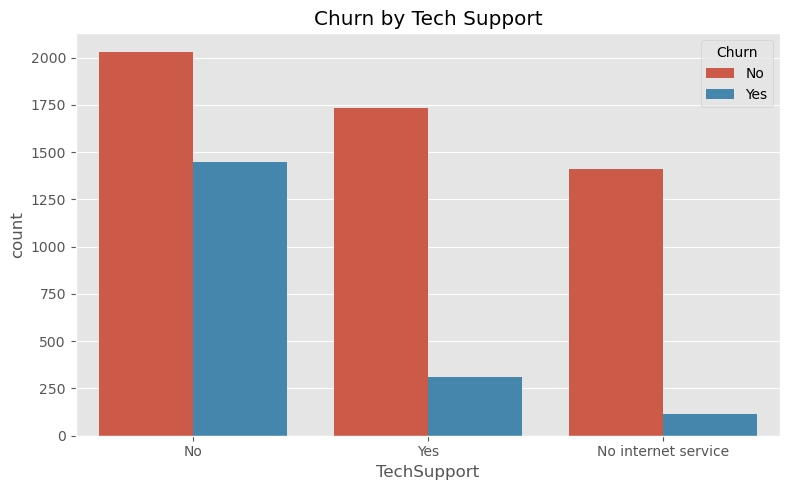

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Churn by Tech Support")

plt.tight_layout()
plt.show()

In [53]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index").mul(100).round(1)

Churn,No,Yes
TechSupport,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2


## Interpretation

Customers without Tech Support have the highest churn rate at 41.6%, compared with 15.2% for customers who subscribe to Tech Support and 7.4% for customers without internet service. Similar to the Online Security analysis, this suggests a strong association between access to support services and customer retention, although causation cannot be established from this analysis alone.

---

# Online Backup

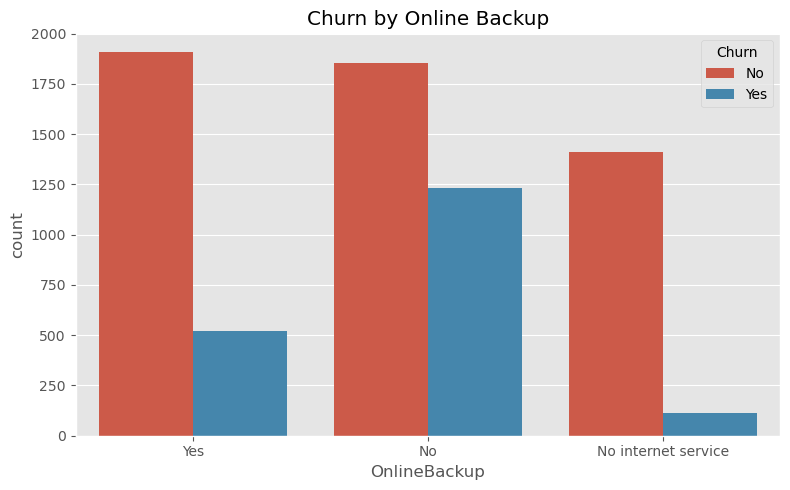

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="OnlineBackup", hue="Churn")

plt.title("Churn by Online Backup")

plt.tight_layout()
plt.show()

In [54]:
pd.crosstab(df["OnlineBackup"], df["Churn"], normalize="index").mul(100).round(1)

Churn,No,Yes
OnlineBackup,,
No,60.1,39.9
No internet service,92.6,7.4
Yes,78.5,21.5


## Interpretation

Customers without Online Backup have the highest churn rate at 39.9%, compared with 21.5% for customers who subscribe to Online Backup and 7.4% for customers without internet service. This indicates an association between Online Backup subscription and customer retention. While customers with Online Backup experience considerably lower churn, this analysis identifies an association rather than proving that the service itself reduces churn.

---

# Device Protection

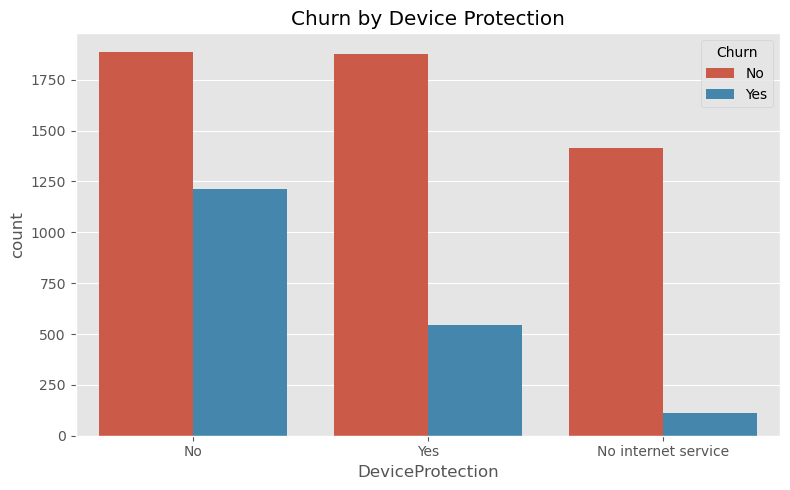

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="DeviceProtection", hue="Churn")

plt.title("Churn by Device Protection")

plt.tight_layout()
plt.show()

In [55]:
pd.crosstab(df["DeviceProtection"], df["Churn"], normalize="index").mul(100).round(1)

Churn,No,Yes
DeviceProtection,,
No,60.9,39.1
No internet service,92.6,7.4
Yes,77.5,22.5


## Interpretation

Customers without Device Protection have the highest churn rate at 39.1%, compared with 22.5% for customers who subscribe to Device Protection and 7.4% for customers without internet service. This suggests that Device Protection is associated with improved customer retention, although the analysis does not establish a causal relationship between the service and reduced churn.

---

# Churn by Tenure

<Axes: xlabel='tenure', ylabel='Count'>

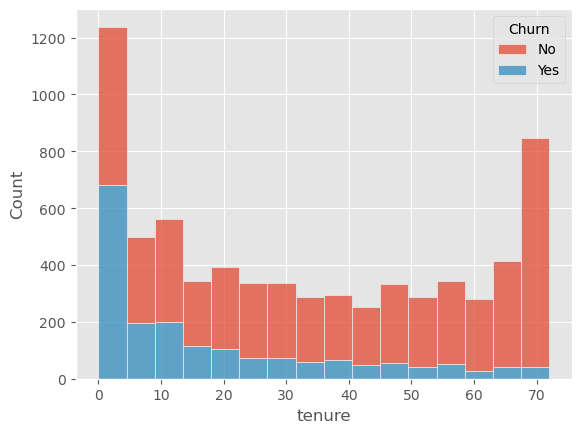

In [43]:
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack")

## Interpretation
The stacked histogram shows that churn is concentrated among customers with shorter tenures, particularly within the first 10 months of service, where churned customers account for a substantial proportion of customers in those tenure ranges. As tenure increases, the number and proportion of churned customers generally decline, and customers with the longest tenures (around 70–72 months) are overwhelmingly retained. This pattern suggests an association between longer customer tenure and higher retention, although the chart alone does not establish that longer tenure causes customers to remain.